In [57]:
import numpy as np
from cnmf import cNMF
import pandas as pd
import spatialdata as sd
import spatialdata_plot
import scanpy as sc
import squidpy as sq

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


## K sweep

In [7]:
# Initialize --------------------------------------------------
OUTPUT_DIR = "/Users/mzarodniuk/Documents/Scripts/Alice_Xenium/results/xenium"
COUNT_PATH = "/Users/mzarodniuk/Documents/Scripts/Alice_Xenium/data/merged_xenium_sdata.h5ad"
NUM_ITER = 50
NUM_HV_GENES = 5000
SEED = 42
NUM_WORKERS = 10
RUN_NAME = "sweep"
K_VALUES = list(range(2, 11))

# Run cNMF --------------------------------------------------
cnmf_obj = cNMF(output_dir=OUTPUT_DIR, name=RUN_NAME)

cnmf_obj.prepare(
    counts_fn=COUNT_PATH,
    components=np.arange(2, 11),
    n_iter=NUM_ITER,
    seed=SEED,
    num_highvar_genes=NUM_HV_GENES
)

cnmf_obj.factorize_multi_process(total_workers=NUM_WORKERS)

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/cnmf/cnmf.py:616: UserWarning: 85 runs already appear completed. If this is unexpected, consider
            re-initializing the cnmf object with a different run name or output directory
  warnings.warn(message, UserWarning)


[Worker 8]. Starting task 8.
[Worker 2]. Starting task 2.
[Worker 1]. Starting task 1.
[Worker 3]. Starting task 3.
[Worker 0]. Starting task 0.
[Worker 6]. Starting task 6.
[Worker 4]. Starting task 4.
[Worker 9]. Starting task 9.
[Worker 5]. Starting task 5.
[Worker 7]. Starting task 7.
[Worker 0]. Starting task 10.
[Worker 8]. Starting task 18.
[Worker 2]. Starting task 12.
[Worker 1]. Starting task 11.
[Worker 3]. Starting task 13.
[Worker 4]. Starting task 14.
[Worker 5]. Starting task 15.
[Worker 7]. Starting task 17.
[Worker 6]. Starting task 16.
[Worker 9]. Starting task 19.
[Worker 8]. Starting task 28.
[Worker 1]. Starting task 21.
[Worker 3]. Starting task 23.
[Worker 2]. Starting task 22.
[Worker 0]. Starting task 20.
[Worker 4]. Starting task 24.
[Worker 5]. Starting task 25.
[Worker 6]. Starting task 26.
[Worker 9]. Starting task 29.
[Worker 7]. Starting task 27.
[Worker 8]. Starting task 38.
[Worker 3]. Starting task 33.
[Worker 6]. Starting task 36.
[Worker 2]. Starting

Combining factorizations for k=2.
Combining factorizations for k=3.
Combining factorizations for k=4.
Combining factorizations for k=5.
Combining factorizations for k=6.
Combining factorizations for k=7.
Combining factorizations for k=8.
Combining factorizations for k=9.
Combining factorizations for k=10.


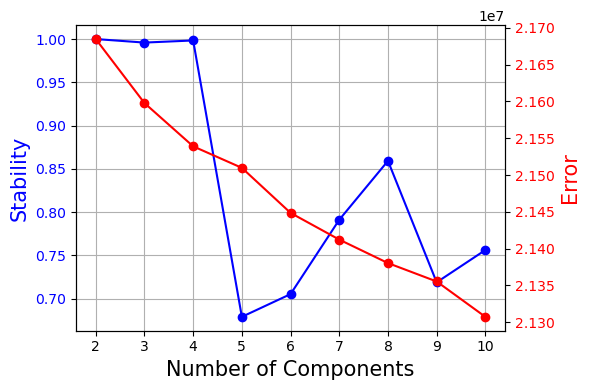

In [8]:
cnmf_obj.combine()
cnmf_obj.k_selection_plot(close_fig=False)

## K=4 factorization

In [9]:
RUN_NAME = "k4"
NUM_ITER = 500

# Run cNMF --------------------------------------------------
cnmf_obj = cNMF(output_dir=OUTPUT_DIR, name=RUN_NAME)

cnmf_obj.prepare(
    counts_fn=COUNT_PATH,
    components=4,
    n_iter=NUM_ITER,
    seed=SEED,
    num_highvar_genes=NUM_HV_GENES
)

cnmf_obj.factorize_multi_process(total_workers=NUM_WORKERS)

[Worker 1]. Starting task 1.
[Worker 7]. Starting task 7.
[Worker 0]. Starting task 0.
[Worker 6]. Starting task 6.
[Worker 3]. Starting task 3.
[Worker 8]. Starting task 8.
[Worker 9]. Starting task 9.
[Worker 4]. Starting task 4.
[Worker 2]. Starting task 2.
[Worker 5]. Starting task 5.
[Worker 6]. Starting task 16.
[Worker 7]. Starting task 17.
[Worker 2]. Starting task 12.
[Worker 1]. Starting task 11.
[Worker 9]. Starting task 19.
[Worker 8]. Starting task 18.
[Worker 3]. Starting task 13.
[Worker 5]. Starting task 15.
[Worker 4]. Starting task 14.
[Worker 0]. Starting task 10.
[Worker 6]. Starting task 26.
[Worker 4]. Starting task 24.
[Worker 1]. Starting task 21.
[Worker 9]. Starting task 29.
[Worker 3]. Starting task 23.
[Worker 0]. Starting task 20.
[Worker 2]. Starting task 22.
[Worker 4]. Starting task 34.
[Worker 7]. Starting task 27.
[Worker 6]. Starting task 36.
[Worker 5]. Starting task 25.
[Worker 1]. Starting task 31.
[Worker 4]. Starting task 44.
[Worker 8]. Starting

Combining factorizations for k=4.


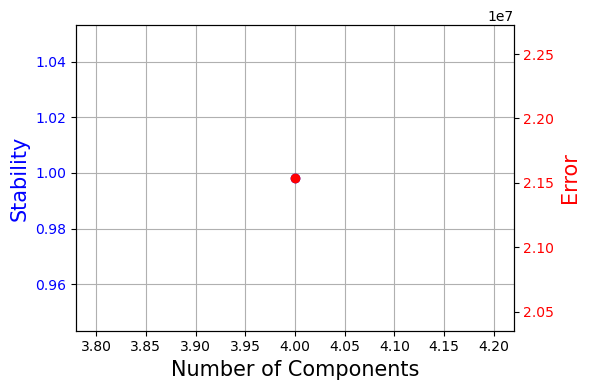

In [11]:
cnmf_obj.combine()
cnmf_obj.k_selection_plot(close_fig=False)

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


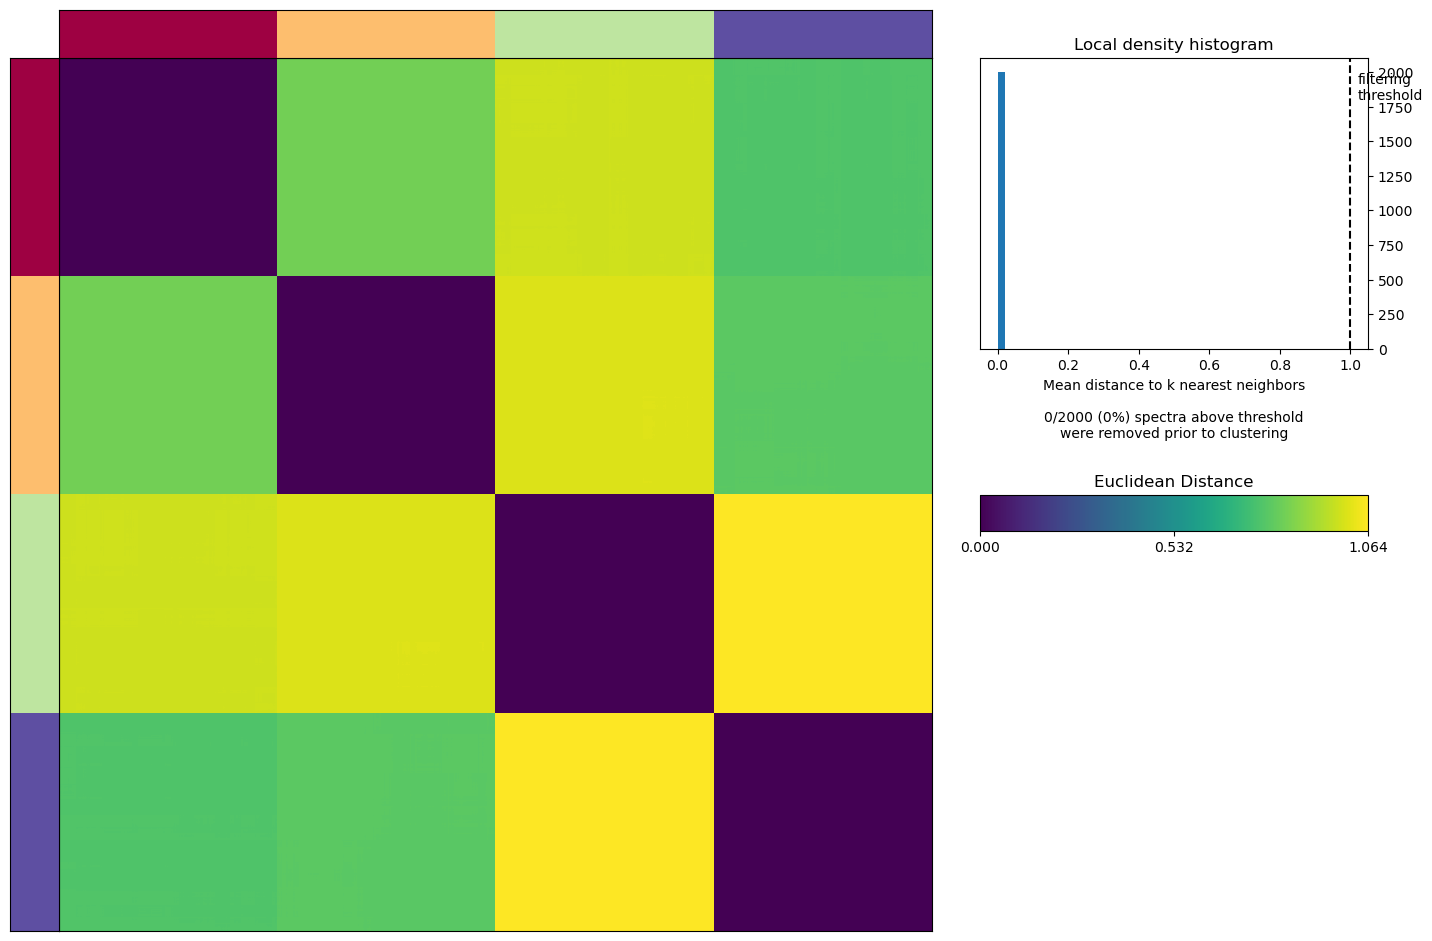

In [12]:
cnmf_obj.consensus(k=4, density_threshold=1, show_clustering=True, close_clustergram_fig=False)

In [13]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=4, density_threshold=1)
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]

In [20]:
usage_norm.to_csv(f"{OUTPUT_DIR}/xenium_cNMF_k4_usage_norm.csv")
gep_scores.to_csv(f"{OUTPUT_DIR}/xenium_cNMF_k4_gep_scores.csv")
gep_tpm.to_csv(f"{OUTPUT_DIR}/xenium_cNMF_k4_gep_tpm.csv")
topgenes.to_csv(f"{OUTPUT_DIR}/xenium_cNMF_k4_topgenes.csv")

## Plotting

In [163]:
adata = sc.read_h5ad("/Users/mzarodniuk/Documents/Scripts/Alice_Xenium/data/merged_xenium_sdata.h5ad")

In [164]:
adata.obs = pd.merge(left=adata.obs, right=usage_norm, how='left', left_index=True, right_index=True)

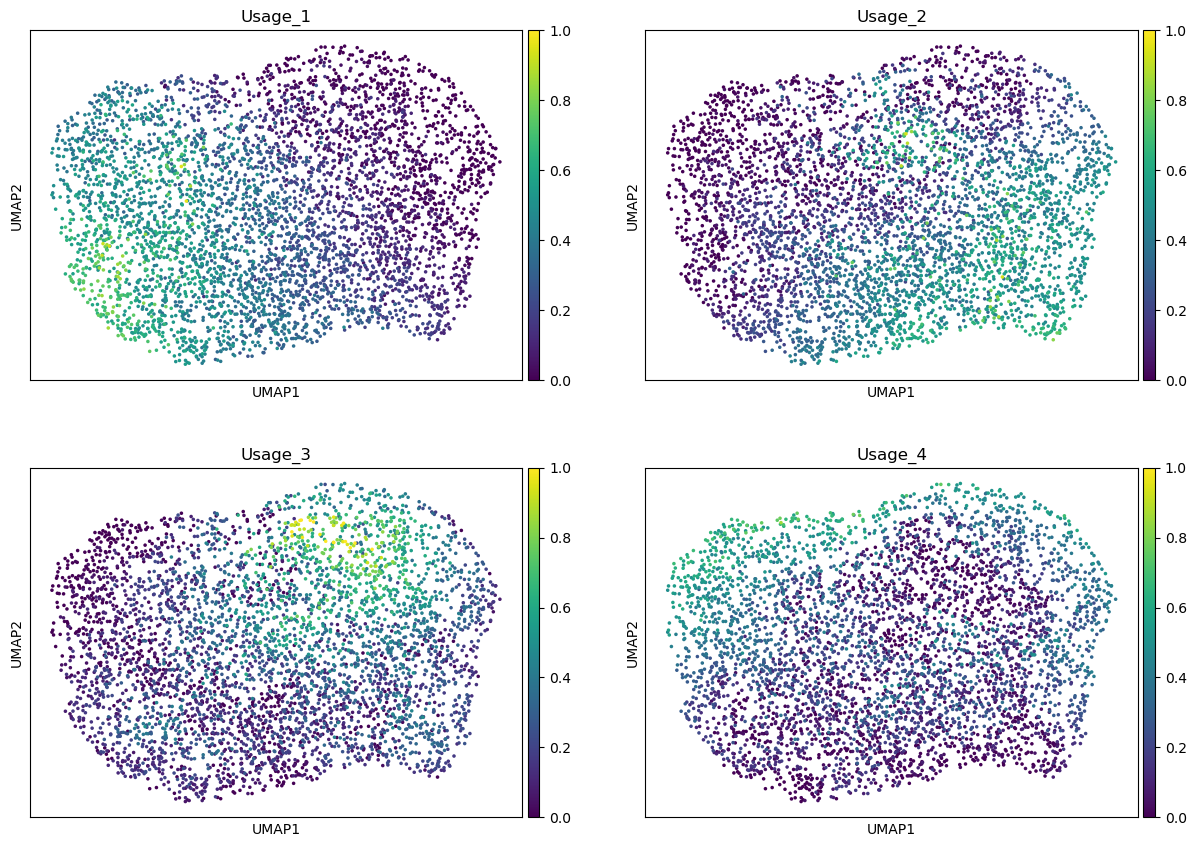

In [328]:
sc.pl.umap(adata, color=usage_norm.columns, ncols=2, vmin=0, vmax=1)

In [167]:
topgenes = topgenes.head(50)
adata = adata_score_by_gep(adata, topgenes)

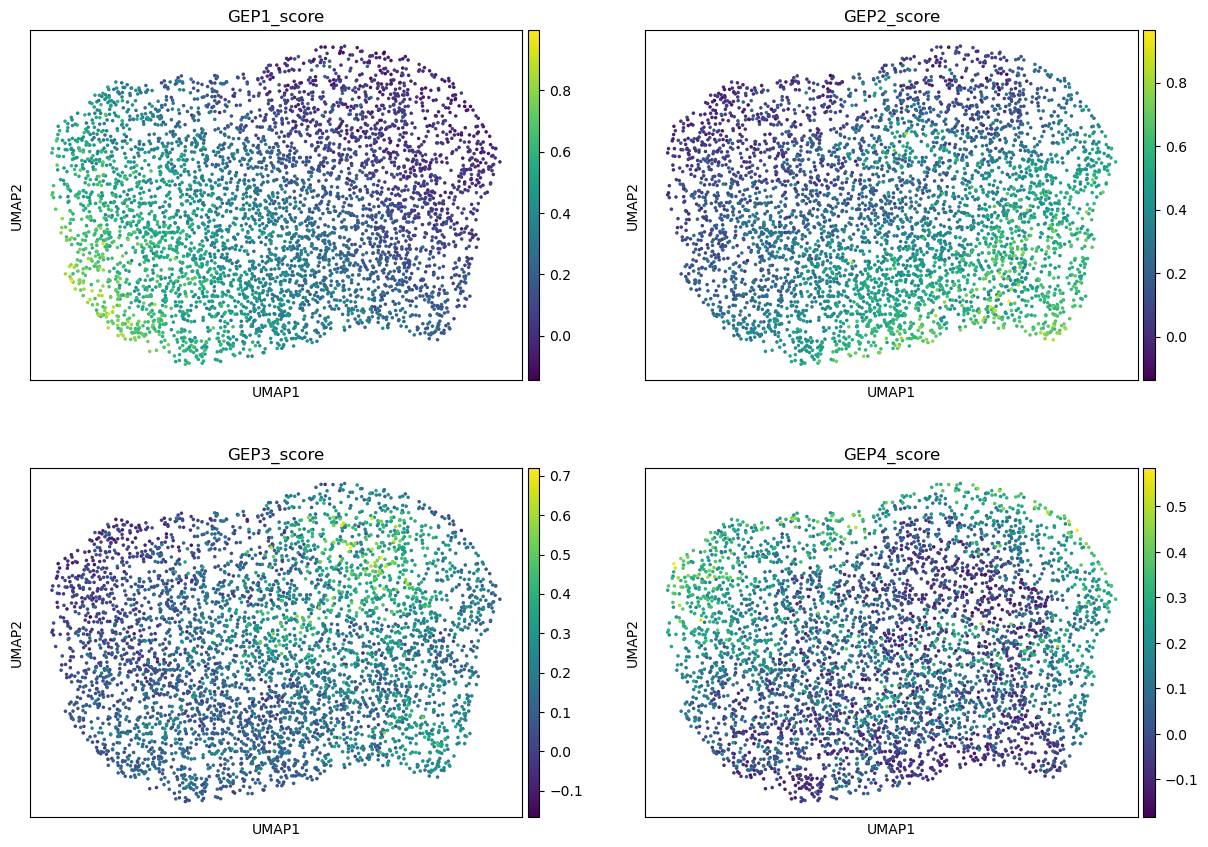

In [168]:
sc.pl.umap(adata, color=["GEP1_score", "GEP2_score", "GEP3_score", "GEP4_score"], ncols=2)

In [ ]:
def permute_adata(adata, random_state):

    adata_permuted = adata.copy()
    X = np.array(adata.X.copy().toarray())

    np.random.seed(random_state)
    np.apply_along_axis(np.random.shuffle, 0, X)

    adata_permuted.X = X
    return(adata_permuted)

def adata_score_by_gep(adata, topgenes):

    for j in range(topgenes.shape[1]):
        j = j+1
        gene_list = topgenes[j].values
        sc.tl.score_genes(adata, gene_list=gene_list, score_name=f'GEP{j}_score')    
    
    return(adata)

B = 100
random_states = np.arange(0, B)
cols = [f"GEP{i}_score" for i in range(1, (topgenes.shape[1]+1))]

In [145]:
M = []

for i in range(B):
    print(f"Permutation {i+1} / {B}")
    adata_permuted = permute_adata(adata, random_states[i])
    adata_permuted = adata_score_by_gep(adata_permuted, topgenes)
    M.append(np.array(adata_permuted.obs[cols]))

Permutation 1 / 100
Permutation 2 / 100
Permutation 3 / 100
Permutation 4 / 100
Permutation 5 / 100
Permutation 6 / 100
Permutation 7 / 100
Permutation 8 / 100
Permutation 9 / 100
Permutation 10 / 100
Permutation 11 / 100
Permutation 12 / 100
Permutation 13 / 100
Permutation 14 / 100
Permutation 15 / 100
Permutation 16 / 100
Permutation 17 / 100
Permutation 18 / 100
Permutation 19 / 100
Permutation 20 / 100
Permutation 21 / 100
Permutation 22 / 100
Permutation 23 / 100
Permutation 24 / 100
Permutation 25 / 100
Permutation 26 / 100
Permutation 27 / 100
Permutation 28 / 100
Permutation 29 / 100
Permutation 30 / 100
Permutation 31 / 100
Permutation 32 / 100
Permutation 33 / 100
Permutation 34 / 100
Permutation 35 / 100
Permutation 36 / 100
Permutation 37 / 100
Permutation 38 / 100
Permutation 39 / 100
Permutation 40 / 100
Permutation 41 / 100
Permutation 42 / 100
Permutation 43 / 100
Permutation 44 / 100
Permutation 45 / 100
Permutation 46 / 100
Permutation 47 / 100
Permutation 48 / 100
P

In [147]:
M = np.vstack(M)
M.shape

(459000, 4)

In [177]:
M_mu = np.mean(M, axis=0)
M_sigma = np.std(M, axis=0)

In [178]:
P = np.zeros((adata.shape[0], topgenes.shape[1]))

for i in range(adata.shape[0]):
    for j in range(topgenes.shape[1]):
        mu = np.mean(M[:, j])
        sigma = np.std(M[:, j])
        x = adata.obs[cols[j]].values[i]
        P[i, j] = 1 - norm.cdf(x, loc=M_mu[j], scale=M_sigma[j])

P

array([[9.99992193e-01, 9.96248915e-01, 3.48138748e-01, 9.85628196e-01],
       [9.95844901e-01, 1.69331434e-02, 9.86895369e-01, 6.22263424e-01],
       [9.99213907e-01, 4.50669206e-01, 3.27134224e-01, 9.98233756e-01],
       ...,
       [9.99753939e-01, 2.64909613e-01, 9.37112473e-01, 1.48801252e-04],
       [9.90666920e-01, 9.99986425e-01, 9.89657991e-01, 1.14903887e-01],
       [5.75861457e-01, 9.99503853e-01, 6.70895244e-01, 9.59893914e-01]])

In [229]:
from statsmodels.stats.multitest import multipletests

P_adj = P.copy()

for i in range(P.shape[1]):
    P_adj[:,i] = multipletests(P[:,i], method='fdr_bh')[1]

In [304]:
gep_assignments = dict()

for i in range(P_adj.shape[0]):
    gep_assignments[i] = ",".join([str(i+1) for i in np.where(P[i,:]<0.05)[0]])

tbl = pd.Series(gep_assignments).value_counts()
print(tbl)

         937
1        803
2        739
3        627
4        555
1,4      282
2,4      174
2,3      173
1,2      164
3,4       84
1,3       29
1,2,4     13
2,3,4      8
1,2,3      2
Name: count, dtype: int64


In [311]:
adata.obs["GEP_assignment"] = ["NA" if i=="" else i for i in list(gep_assignments.values())]

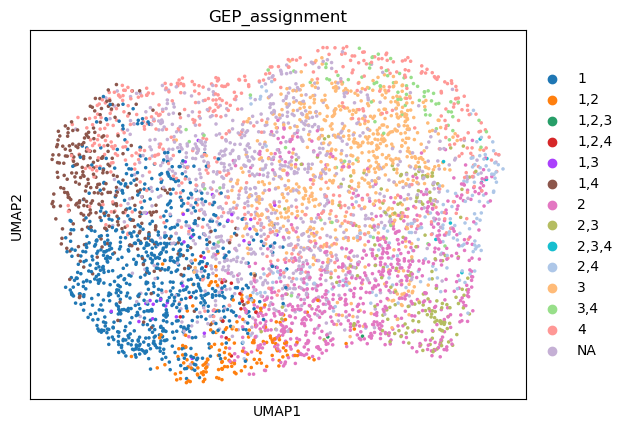

In [306]:
sc.pl.umap(adata, color=["GEP_assignment"])

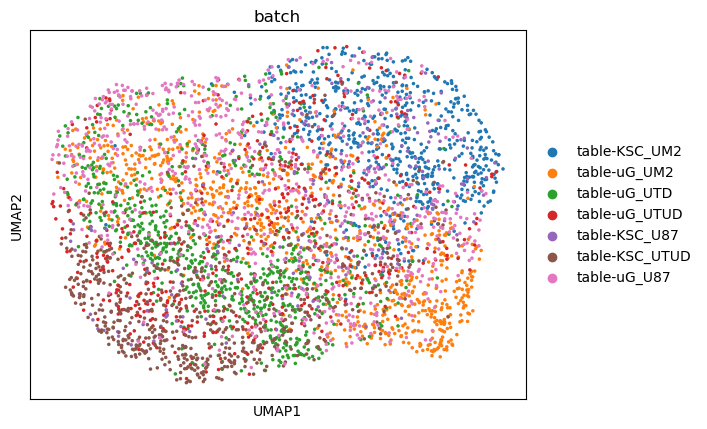

In [307]:
sc.pl.umap(adata, color=["batch"])

In [323]:
tbl

col_0,False,True
batch,,
table-KSC_UM2,655,1
table-uG_UM2,764,157
table-uG_UTD,457,368
table-uG_UTUD,333,180
table-KSC_U87,203,44
table-KSC_UTUD,249,402
table-uG_U87,636,141


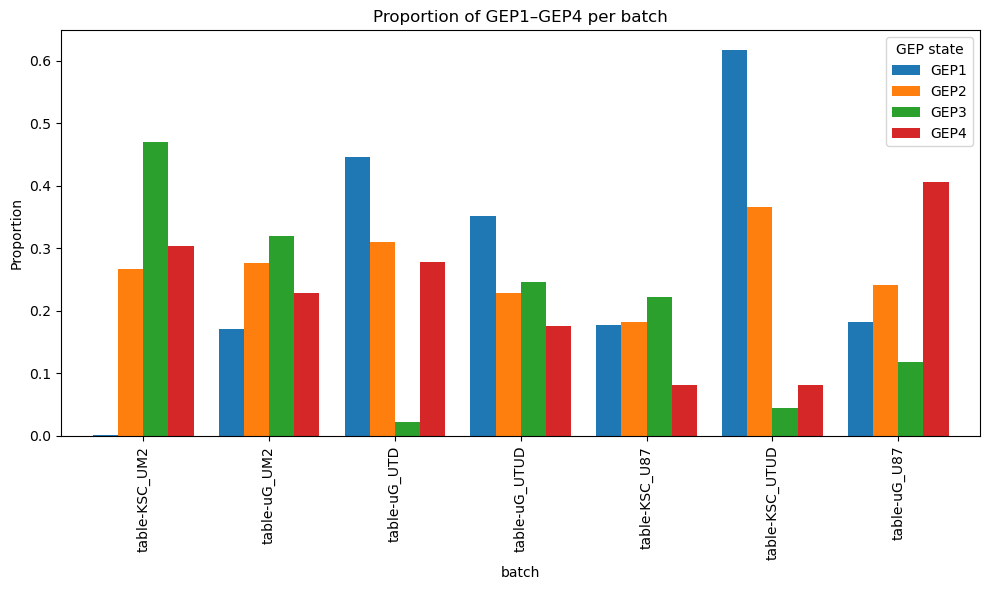

In [327]:
import pandas as pd
import matplotlib.pyplot as plt

df = adata.obs

# Define which GEP labels you want to track
geps = ["1", "2", "3", "4"]

# Build a dataframe: rows = batch, columns = GEP1–4, values = proportions
tbl_list = []
for g in geps:
    col = df["GEP_assignment"].str.contains(g)  # Boolean for each GEP
    tbl = pd.crosstab(df["batch"], col)
    tbl_norm = tbl.div(tbl.sum(axis=1), axis=0)
    tbl_list.append(tbl_norm[True])   # Only keep the TRUE column

# Combine into a single DF
gep_df = pd.concat(tbl_list, axis=1)
gep_df.columns = [f"GEP{g}" for g in geps]

# Plot
ax = gep_df.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # GEP1–4 colors
)

plt.ylabel("Proportion")
plt.title("Proportion of GEP1–GEP4 per batch")
plt.legend(title="GEP state")
plt.tight_layout()
plt.show()